In [1]:
!pip install ag2[openai] python-dotenv | tail -n 1


In [2]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
OPENAI_ORG_ID = os.getenv("OPENAI_ORG_ID", "")

# Model Configuration
DEFAULT_MODEL = os.getenv("DEFAULT_MODEL", "gpt-3.5-turbo")
TEMPERATURE = float(os.getenv("TEMPERATURE", "0.7"))
MAX_TOKENS = int(os.getenv("MAX_TOKENS", "500"))
WATSON_URL = os.getenv("IBM_URL_END_POINT")
PROJECT_ID = os.getenv("IBM_PROJECT_ID")
IBM_API_KEY = os.getenv("IBM_API_KEY")
TAVILY_KEY = os.getenv("TAVILY_API_KEY")
SERPER_API_KEY = os.getenv("SERPER_API_KEY")

In [ ]:
# Import necessary modules
import os
from autogen import ConversableAgent, AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
from autogen.llm_config import LLMConfig
import json
import time
import random

# Load environment variables
load_dotenv()

print("AG2 modules imported successfully!")

AG2 modules imported successfully!


In [ ]:
import logging

# Suppress API key format warning
logging.getLogger("autogen.oai.client").setLevel(logging.ERROR)

In [4]:
# # Create a configuration file for your API keys
# # Replace with your actual API key
config_list = [
    {
        "model": "gpt-4",
        "api_key": OPENAI_API_KEY,
    }
]

# Alternatively, you can create a JSON file
# '''
# with open('config.json', 'w') as f:
#    json.dump(config_list, f)
    
# Then load it
# config_list = config_list_from_json("config.json")
# '''

In [5]:
from autogen import ConversableAgent

# LLM configuration (API key will be taken from environment variable)
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ]
}

# Student agent
student = ConversableAgent(
    name="student",
    system_message="You are a curious student. You ask clear, specific questions to learn new concepts.",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Tutor agent
tutor = ConversableAgent(
    name="tutor",
    system_message="You are a helpful tutor who provides clear and concise explanations suitable for a beginner.",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Start conversation
chat_result = student.initiate_chat(
    recipient=tutor,
    message="Can you explain what a neural network is?",
    max_turns=2,
    summary_method="reflection_with_llm"
)

print("\nFinal Summary:")
print(chat_result.summary)

student (to tutor):

Can you explain what a neural network is?

--------------------------------------------------------------------------------
tutor (to student):

Sure! A neural network is a type of artificial intelligence model that is designed to recognize patterns and learn from data, similar to how the human brain works. Here are the key concepts you should understand:

1. **Layered Structure**: A neural network consists of layers of interconnected nodes, also known as neurons. These include:
   - **Input Layer**: This is where data enters the network. Each neuron in this layer represents a feature of the input data (like pixels in an image).
   - **Hidden Layers**: These layers process the information received from the input layer. There can be many hidden layers, and this is where the network learns to recognize complex patterns.
   - **Output Layer**: This is where the network produces its predictions or classifications based on the processed information.

2. **Neurons and We

In [6]:
# Create a Technical Expert Agent
tech_expert = ConversableAgent(
    name="tech_expert",
    system_message="""You are a senior software engineer with expertise in Python, AI, and system design.
    Provide technical, detailed explanations with code examples when appropriate.
    Always consider best practices and performance implications.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Create a Creative Writer Agent
creative_writer = ConversableAgent(
    name="creative_writer",
    system_message="""You are a creative writer and storyteller.
    Your responses are engaging, imaginative, and use vivid descriptions.
    You excel at making complex topics accessible through stories and analogies.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Create a Business Analyst Agent
business_analyst = ConversableAgent(
    name="business_analyst",
    system_message="""You are a business analyst focused on ROI, efficiency, and strategic planning.
    Always consider business impact, costs, and practical implementation.
    Provide actionable recommendations with clear metrics.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

agents = [tech_expert, creative_writer, business_analyst]
print("Specialized agents created!")
for agent in agents:
    print(f"- {agent.name}: {agent.system_message.split('.')[0]}.")

Specialized agents created!
- tech_expert: You are a senior software engineer with expertise in Python, AI, and system design.
- creative_writer: You are a creative writer and storyteller.
- business_analyst: You are a business analyst focused on ROI, efficiency, and strategic planning.


user_proxy (to assistant):

Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.

--------------------------------------------------------------------------------
assistant (to user_proxy):

To plot a sine wave using Matplotlib and save it as `sine_wave.png`, you can follow the steps in the code below. This code will create the sine wave, label the axes, add a title to the plot, and then save the resulting figure to a file.

Here’s the code:

```python
import numpy as np
import matplotlib.pyplot as plt

# Define the x values from -2π to 2π
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)  # 1000 points in that range
# Calculate the sine of x
y = np.sin(x)

# Create the plot
plt.figure(figsize=(10, 5))  # Set the figure size
plt.plot(x, y, label='sin(x)', color='blue')  # Plot the sine wave
plt.title('Sine Wave')
plt.xlabel('x (radians)')
plt.ylabel('sin(x)')
plt.axhline(0, color='black', lw=0.5, ls='--')  # Add x-axis
plt.axvline(0, color='black', lw=0.5, ls

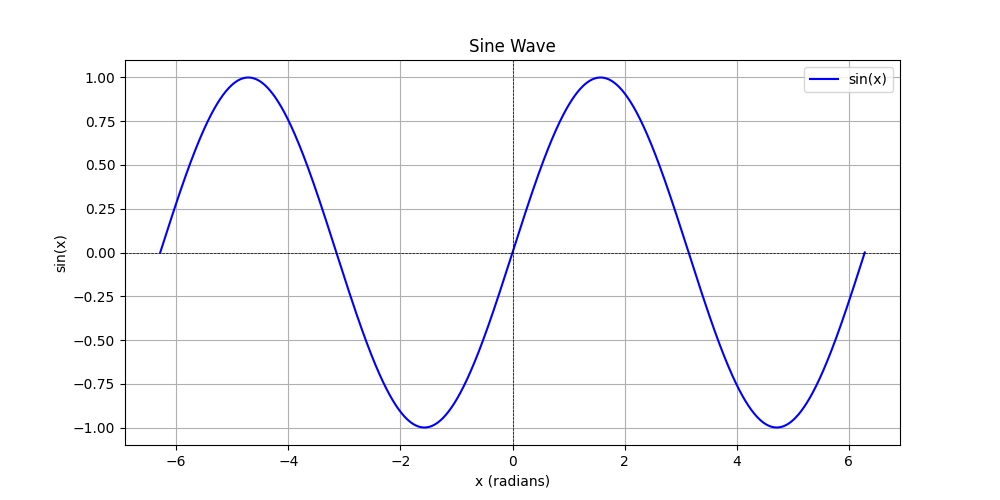


Final Summary:
The conversation involved generating a sine wave plot using Matplotlib, saving it as `sine_wave.png`, and confirming the successful execution of the code. The user was prompted to ask further questions or request assistance as needed.


In [7]:
# Requirements:
# !pip install matplotlib numpy pyautogen

from autogen import AssistantAgent, UserProxyAgent
from autogen.coding import LocalCommandLineCodeExecutor

# Step 1: LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ]
}

# Step 2: Create assistant agent
assistant = AssistantAgent(
    name="assistant",
    system_message="You are a helpful assistant who writes and explains Python code clearly.",
    llm_config=llm_config
)

# Step 3: Create user proxy agent
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=5,
    code_execution_config={
        "executor": LocalCommandLineCodeExecutor(work_dir="coding", timeout=30),
    },
)

# Step 4: Start task
chat_result = user_proxy.initiate_chat(
    recipient=assistant,
    message="Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.",
    max_turns=4,
    summary_method="reflection_with_llm"
)

# Step 5: Display image
from IPython.display import Image, display
import os

image_path = "coding/sine_wave.png"
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print("Plot not found.")

# Step 6: Print summary
print("\nFinal Summary:")
print(chat_result.summary)

In [8]:
from autogen import ConversableAgent
import random

# Step 1: LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ]
}

# Step 2: Define system message
triage_system_message = """
You are a bug triage assistant. You will be given bug report summaries.

For each bug:
- If it is urgent (e.g., 'crash', 'security', or 'data loss' is mentioned), escalate it and ask the human agent for confirmation.
- If it seems minor (e.g., cosmetic, typo), suggest closing it but still ask for human review.
- Otherwise, classify it as medium priority and ask the human for review.

Once all bugs are processed, summarize what was escalated, closed, or marked as medium priority.
End by saying: "You can type exit to finish."
"""

# Step 3: Create assistant agent
triage_bot = ConversableAgent(
    name="triage_bot",
    system_message=triage_system_message,
    llm_config=llm_config
)

# Step 4: Create human agent
human = ConversableAgent(
    name="human",
    human_input_mode="ALWAYS",
)

# Step 5: Generate sample bugs
BUGS = [
    "App crashes when opening user profile.",
    "Minor UI misalignment on settings page.",
    "Password reset email not sent consistently.",
    "Typo in the About Us footer text.",
    "Database connection timeout under heavy load.",
    "Login form allows SQL injection attack.",
]

random.shuffle(BUGS)
selected_bugs = BUGS[:3]

# Step 6: Format prompt
initial_prompt = (
    "Please triage the following bug reports one by one:\n\n" +
    "\n".join([f"{i+1}. {bug}" for i, bug in enumerate(selected_bugs)])
)

# Step 7: Start conversation
human.initiate_chat(
    recipient=triage_bot,
    message=initial_prompt,
)

human (to triage_bot):

Please triage the following bug reports one by one:

1. Database connection timeout under heavy load.
2. Password reset email not sent consistently.
3. Minor UI misalignment on settings page.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
triage_bot (to human):

1. **Database connection timeout under heavy load.**  
   This seems to be a medium priority issue. I recommend reviewing it for further investigation. 

2. **Password reset email not sent consistently.**  
   This is also a medium priority issue. I suggest reviewing it further to ensure functionalities are working as expected.

3. **Minor UI misalignment on settings page.**  
   This is a minor issue. I recommend closing it, but I would like a human review to confirm this.

**Summary:**
- **Escalated:** None
- **Closed:** Minor UI misalignment on settings page (pending human review)
- **Medium Priority:** Database connection timeout under 

ChatResult(chat_id=331276381964818400129697930390830381843, chat_history=[{'content': 'Please triage the following bug reports one by one:\n\n1. Database connection timeout under heavy load.\n2. Password reset email not sent consistently.\n3. Minor UI misalignment on settings page.', 'role': 'assistant', 'name': 'human'}, {'content': '1. **Database connection timeout under heavy load.**  \n   This seems to be a medium priority issue. I recommend reviewing it for further investigation. \n\n2. **Password reset email not sent consistently.**  \n   This is also a medium priority issue. I suggest reviewing it further to ensure functionalities are working as expected.\n\n3. **Minor UI misalignment on settings page.**  \n   This is a minor issue. I recommend closing it, but I would like a human review to confirm this.\n\n**Summary:**\n- **Escalated:** None\n- **Closed:** Minor UI misalignment on settings page (pending human review)\n- **Medium Priority:** Database connection timeout under hea

In [9]:
from autogen import ConversableAgent, GroupChat, GroupChatManager

# LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ]
}

# System messages
planner_message = "Create a short lesson plan for 4th graders."
reviewer_message = "Review a plan and suggest up to 3 brief edits."
teacher_message = "Suggest a topic and reply DONE when satisfied."

# Create agents
lesson_planner = ConversableAgent(
    name="planner_agent",
    system_message=planner_message,
    description="Makes lesson plans.",
    llm_config=llm_config
)

lesson_reviewer = ConversableAgent(
    name="reviewer_agent",
    system_message=reviewer_message,
    description="Reviews lesson plans and suggests edits.",
    llm_config=llm_config
)

teacher = ConversableAgent(
    name="teacher_agent",
    system_message=teacher_message,
    llm_config=llm_config,
    is_termination_msg=lambda x: "DONE" in (x.get("content", "") or "").upper()
)

# Create group chat
groupchat = GroupChat(
    agents=[teacher, lesson_planner, lesson_reviewer],
    speaker_selection_method="auto"
)

# Create manager
manager = GroupChatManager(
    name="group_manager",
    groupchat=groupchat,
    llm_config=llm_config
)

# Start chat
teacher.initiate_chat(
    recipient=manager,
    message="Make a simple lesson about Women's marathoning history.",
    max_turns=6,
    summary_method="reflection_with_llm"
)

teacher_agent (to group_manager):

Make a simple lesson about Women's marathoning history.

--------------------------------------------------------------------------------

Next speaker: planner_agent


>>>>>>>> USING AUTO REPLY...
planner_agent (to group_manager):

### Lesson Plan: The History of Women's Marathoning

**Grade Level**: 4th Grade  
**Subject**: Physical Education / History  
**Duration**: 45 minutes

---

#### Objective:
Students will understand the history of women's participation in marathoning, recognize key figures and milestones, and appreciate the significance of women's achievements in the sport.

#### Materials Needed:
- Whiteboard and markers
- Projector and screen (optional)
- Pictures of notable female marathoners (e.g., Kathrine Switzer, Joan Benoit Samuelson)
- Handouts with a timeline of women in marathoning
- Video clip of key moments in women's marathoning history
- Running shoes and space for demonstration (optional)

#### Lesson Outline:

1. **Introduc

ChatResult(chat_id=43086239123415786511622207317547905085, chat_history=[{'content': "Make a simple lesson about Women's marathoning history.", 'role': 'assistant', 'name': 'teacher_agent'}, {'content': "### Lesson Plan: The History of Women's Marathoning\n\n**Grade Level**: 4th Grade  \n**Subject**: Physical Education / History  \n**Duration**: 45 minutes\n\n---\n\n#### Objective:\nStudents will understand the history of women's participation in marathoning, recognize key figures and milestones, and appreciate the significance of women's achievements in the sport.\n\n#### Materials Needed:\n- Whiteboard and markers\n- Projector and screen (optional)\n- Pictures of notable female marathoners (e.g., Kathrine Switzer, Joan Benoit Samuelson)\n- Handouts with a timeline of women in marathoning\n- Video clip of key moments in women's marathoning history\n- Running shoes and space for demonstration (optional)\n\n#### Lesson Outline:\n\n1. **Introduction (10 minutes)**\n   - Begin with a brie

In [10]:
from autogen import ConversableAgent, register_function
from typing import Annotated

# Step 1: LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ]
}

# Step 2: Define function
def is_prime(n: Annotated[int, "Positive integer"]) -> str:
    if n < 2:
        return "No"
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return "No"
    return "Yes"

# Step 3: Create agents
math_asker = ConversableAgent(
    name="math_asker",
    system_message="Ask whether a number is prime.",
    llm_config=llm_config
)

math_checker = ConversableAgent(
    name="math_checker",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Step 4: Register function
register_function(
    is_prime,
    caller=math_asker,
    executor=math_checker,
    description="Check if a number is prime. Returns Yes or No."
)

# Step 5: Start conversation
math_checker.initiate_chat(
    recipient=math_asker,
    message="Is 72 a prime number?",
    max_turns=2
)

math_checker (to math_asker):

Is 72 a prime number?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
math_asker (to math_checker):

***** Suggested tool call (call_Jkug46dAIoAR2XHKGeuzkx4q): is_prime *****
Arguments: 
{"n":72}
*************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION is_prime...
Call ID: call_Jkug46dAIoAR2XHKGeuzkx4q
Input arguments: {'n': 72}

>>>>>>>> EXECUTED FUNCTION is_prime...
Call ID: call_Jkug46dAIoAR2XHKGeuzkx4q
Input arguments: {'n': 72}
Output:
No
math_checker (to math_asker):

***** Response from calling tool (call_Jkug46dAIoAR2XHKGeuzkx4q) *****
No
**********************************************************************

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
math_asker (to math_checker):

No, 72 is 

ChatResult(chat_id=29648492314507799595500490182818850314, chat_history=[{'content': 'Is 72 a prime number?', 'role': 'assistant', 'name': 'math_checker'}, {'tool_calls': [{'id': 'call_Jkug46dAIoAR2XHKGeuzkx4q', 'function': {'arguments': '{"n":72}', 'name': 'is_prime'}, 'type': 'function'}], 'content': None, 'role': 'assistant'}, {'content': 'No', 'tool_responses': [{'tool_call_id': 'call_Jkug46dAIoAR2XHKGeuzkx4q', 'role': 'tool', 'content': 'No'}], 'role': 'tool', 'name': 'math_checker'}, {'content': 'No, 72 is not a prime number.', 'role': 'user', 'name': 'math_asker'}], summary='No, 72 is not a prime number.', cost={'usage_including_cached_inference': {'total_cost': 3.945e-05, 'gpt-4o-mini-2024-07-18': {'cost': 3.945e-05, 'prompt_tokens': 163, 'completion_tokens': 25, 'total_tokens': 188}}, 'usage_excluding_cached_inference': {'total_cost': 3.945e-05, 'gpt-4o-mini-2024-07-18': {'cost': 3.945e-05, 'prompt_tokens': 163, 'completion_tokens': 25, 'total_tokens': 188}}}, human_input=[])

In [11]:
from pydantic import BaseModel
from autogen import ConversableAgent

# Define structured output model
class TicketSummary(BaseModel):
    customer_name: str
    issue_type: str
    urgency_level: str
    recommended_action: str

# LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4o-mini"
        }
    ],
    "response_format": TicketSummary
}

# Create agent
support_agent = ConversableAgent(
    name="support_agent",
    system_message=(
        "You are a support assistant. Summarize a customer ticket using:"
        "\n- customer_name"
        "\n- issue_type (e.g. login issue, billing problem, bug report)"
        "\n- urgency_level (Low, Medium, High)"
        "\n- recommended_action"
    ),
    llm_config=llm_config
)

# Start conversation
support_agent.initiate_chat(
    recipient=support_agent,
    message="Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.",
    max_turns=1
)

support_agent (to support_agent):

Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
support_agent (to support_agent):

{"customer_name":"John Doe","issue_type":"login issue","urgency_level":"High","recommended_action":"Assist the customer in resetting the password immediately."}

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (873639e1-6a1a-42c0-8cd3-9664322df130): Maximum turns (1) reached


ChatResult(chat_id=222604028790950510572421760145149497754, chat_history=[{'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'assistant', 'name': 'support_agent'}, {'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'user', 'name': 'support_agent'}, {'content': '{"customer_name":"John Doe","issue_type":"login issue","urgency_level":"High","recommended_action":"Assist the customer in resetting the password immediately."}', 'role': 'assistant', 'name': 'support_agent'}, {'content': '{"customer_name":"John Doe","issue_type":"login issue","urgency_level":"High","recommended_action":"Assist the customer in resetting the password immediately."}', 'role': 'user', 'name': 'support_agent'}], summary='{"customer_name":"John Doe","issue_type":"login issue","urgency_level":"High","recommended_action":"Assist the customer in resetting the password immediately."}', cost={'